In [24]:
# 1. Cài đặt các thư viện cần thiết
!pip install -q mne scikit-learn matplotlib pandas numpy torch seaborn

import os
import warnings
import glob

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns

# Tắt các cảnh báo hệ thống để log chạy sạch sẽ
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")

print("Đã chuẩn bị xong môi trường và các thư viện!")

Đã chuẩn bị xong môi trường và các thư viện!


In [25]:
# Đường dẫn trực tiếp tới thư mục dữ liệu đã được Kaggle giải nén sẵn
extract_target = "sleep-edf-database-expanded-1.0.0"

# Kiểm tra xem đường dẫn có hoạt động chính xác không
if os.path.exists(extract_target):
    print("✅ Đã kết nối thành công tới bộ dữ liệu Sleep-EDF!")
    print("Các thư mục con sẵn sàng sử dụng:")
    
    # Liệt kê các file/thư mục bên trong để chắc chắn
    files = os.listdir(extract_target)
    for f in files:
        print(f" - {f}")
else:
    print("⚠️ Không tìm thấy thư mục dữ liệu, vui lòng kiểm tra lại đường dẫn.")

✅ Đã kết nối thành công tới bộ dữ liệu Sleep-EDF!
Các thư mục con sẵn sàng sử dụng:
 - RECORDS-v1
 - sleep-cassette
 - RECORDS
 - .DS_Store
 - SC-subjects.xls
 - sleep-telemetry
 - SHA256SUMS.txt
 - ST-subjects.xls


In [26]:
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
VALID_STAGES = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R']
MAPPING_STAGES = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}

def filter_wake_epochs(epochs, wake_id=0, padding_minutes=0, max_break_minutes=45):
    labels = epochs.events[:, -1]
    total_len = len(labels)

    padding_epochs = int(padding_minutes * 60 / 30)
    max_break_epochs = int(max_break_minutes * 60 / 30)

    non_wake_indices = np.where(labels != wake_id)[0]
    if len(non_wake_indices) == 0:
        return epochs
    last_sleep_idx = non_wake_indices[-1]

    first_sleep_idx = non_wake_indices[0]
    current_wake_streak = 0
    has_slept = False

    for i in range(total_len):
        if labels[i] != wake_id:
            if not has_slept:
                first_sleep_idx = i
                has_slept = True

            current_wake_streak = 0
        else:
            if has_slept:
                current_wake_streak += 1

                if current_wake_streak >= max_break_epochs:
                    has_slept = False
                    current_wake_streak = 0
                    print(
                        f"--> Gặp đoạn Wake dài {max_break_minutes} phút tại epoch {i}. Reset lại điểm bắt đầu.")

    start_idx = max(0, first_sleep_idx - padding_epochs)
    end_idx = min(total_len - 1, last_sleep_idx + padding_epochs)

    if start_idx >= end_idx:
        start_idx = max(0, non_wake_indices[0] - padding_epochs)

    filtered_epochs = epochs[start_idx: end_idx + 1]
    print(
        f"Đã lọc Wake tuần tự. Từ {total_len} còn {len(filtered_epochs)} epochs.")

    return filtered_epochs


def feature_extraction(epochs_obj):
    psd_obj = epochs_obj.compute_psd(method='welch', fmin=0.5, fmax=30.0, n_fft=256, verbose=False)
    psds = psd_obj.get_data()
    freqs = psd_obj.freqs
    data = epochs_obj.get_data()
    
    mne_labels = epochs_obj.events[:, -1]
    
    inv_event_id = {v: k for k, v in epochs_obj.event_id.items()}

    bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30), 'spindle': (12, 14)}
    num_channels = data.shape[1]
    eog_idx = 2 if num_channels > 2 else 0
    emg_idx = 4 if num_channels > 4 else 0

    all_features = []
    for i in range(len(epochs_obj)):
        mne_str_desc = inv_event_id[mne_labels[i]]
        target_mapped_label = MAPPING_STAGES[mne_str_desc]

        f = {"label": target_mapped_label}
        
        eeg_psd = psds[i, 0, :]
        raw_powers = {}

        for band, (fmin, fmax) in bands.items():
            power = max(np.mean(eeg_psd[(freqs >= fmin) & (freqs <= fmax)]), 1e-30)
            f[f"eeg_{band}_power"] = power
            raw_powers[band] = power

        total_power = sum(raw_powers.values()) + 1e-30
        for b in ['theta', 'delta', 'alpha', 'beta']:
            f[f"{b}_ratio"] = raw_powers[b] / total_power

        f["theta_delta_ratio"] = raw_powers["theta"] / (raw_powers["delta"] + 1e-30)
        f["delta_alpha_ratio"] = raw_powers["delta"] / (raw_powers["alpha"] + 1e-30)

        eog_var = np.var(data[i, eog_idx, :])
        emg_rms = np.sqrt(np.mean(data[i, emg_idx, :] ** 2))
        f["eog_var"] = eog_var
        f["emg_rms"] = emg_rms
        f["eog_emg_ratio"] = eog_var / (emg_rms + 1e-30)

        all_features.append(f)
        
    return pd.DataFrame(all_features)

def load_edf_folder(pattern, folder_name=""):
    all_files = glob.glob(pattern, recursive=True)
    psg_files = sorted([f for f in all_files if f.endswith("PSG.edf")])
    hyp_files = sorted([f for f in all_files if f.endswith("Hypnogram.edf")])

    # Định nghĩa thư mục đầu ra của Kaggle
    # output_dir = "/kaggle/working/"
    output_dir = os.path.join("processed_data", folder_name)
    os.makedirs(output_dir, exist_ok=True) # Tạo thư mục nếu chưa có

    # Không cần dùng list dfs = [] để gom dữ liệu lớn nữa
    for psg, hyp in zip(psg_files, hyp_files):
        try:
            # Lấy tên định danh file (Ví dụ: path/to/SC4001E0-PSG.edf -> SC4001E0)
            file_id = os.path.basename(psg).split('-')[0]
            print(f"🔄 Đang xử lý file: {file_id}")

            raw = mne.io.read_raw_edf(psg, preload=True, verbose=False)
            raw.resample(100, verbose=False)
            annotations = mne.read_annotations(hyp)
            raw.set_annotations(annotations[np.isin(annotations.description, VALID_STAGES)], emit_warning=False)
            events, event_id = mne.events_from_annotations(raw, event_id=MAPPING_STAGES, chunk_duration=30.0, verbose=False)
            epochs = mne.Epochs(raw, events, event_id=event_id, tmin=0, tmax=30.0 - (1/raw.info['sfreq']), baseline=None, preload=True, verbose=False)

            print(f'   -> Number of epochs ban đầu: {len(epochs)}')

            # Lọc wake và trích xuất đặc trưng (Kết quả trả về là một DataFrame)
            df_feats = feature_extraction(filter_wake_epochs(epochs))
            
            # ĐẶT TÊN VÀ LƯU FILE CSV TRỰC TIẾP
            csv_filename = f"{file_id}_features.csv"
            csv_path = os.path.join(output_dir, csv_filename)
            
            # Tiến hành ghi file (.to_csv sẽ hoạt động hoàn hảo vì df_feats là DataFrame)
            df_feats.to_csv(csv_path, index=False)
            print(f"💾 Đã lưu đặc trưng thành công vào: {csv_filename}")
            print("-" * 50)

        except Exception as e:
            print(f"❌ Lỗi khi xử lý file {psg}: {e}")
            continue
            
    print("✅ Đã hoàn thành trích xuất và lưu tất cả các file!")
    return None

In [ ]:
print("⏳ Đang trích xuất đặc trưng EDF...")

loaded_file_dfs = load_edf_folder(
    os.path.join(extract_target, "**/sleep-cassette/**/*.edf"), folder_name="cassette"
)

telemetry_dfs = load_edf_folder(
    os.path.join(extract_target, "**/sleep-telemetry/**/*.edf"), folder_name="telemetry"
)

⏳ Đang trích xuất đặc trưng EDF...
🔄 Đang xử lý file: SC4001E0


   -> Number of epochs ban đầu: 2650
--> Gặp đoạn Wake dài 45 phút tại epoch 1831. Reset lại điểm bắt đầu.
Đã lọc Wake tuần tự. Từ 2650 còn 721 epochs.
💾 Đã lưu đặc trưng thành công vào: SC4001E0_features.csv
--------------------------------------------------
🔄 Đang xử lý file: SC4002E0
   -> Number of epochs ban đầu: 2829
--> Gặp đoạn Wake dài 45 phút tại epoch 1965. Reset lại điểm bắt đầu.
Đã lọc Wake tuần tự. Từ 2829 còn 1007 epochs.
💾 Đã lưu đặc trưng thành công vào: SC4002E0_features.csv
--------------------------------------------------
🔄 Đang xử lý file: SC4011E0
   -> Number of epochs ban đầu: 2802
--> Gặp đoạn Wake dài 45 phút tại epoch 1790. Reset lại điểm bắt đầu.
Đã lọc Wake tuần tự. Từ 2802 còn 983 epochs.
💾 Đã lưu đặc trưng thành công vào: SC4011E0_features.csv
--------------------------------------------------
🔄 Đang xử lý file: SC4012E0
   -> Number of epochs ban đầu: 2848
--> Gặp đoạn Wake dài 45 phút tại epoch 1798. Reset lại điểm bắt đầu.
Đã lọc Wake tuần tự. Từ 2848

TypeError: object of type 'NoneType' has no len()

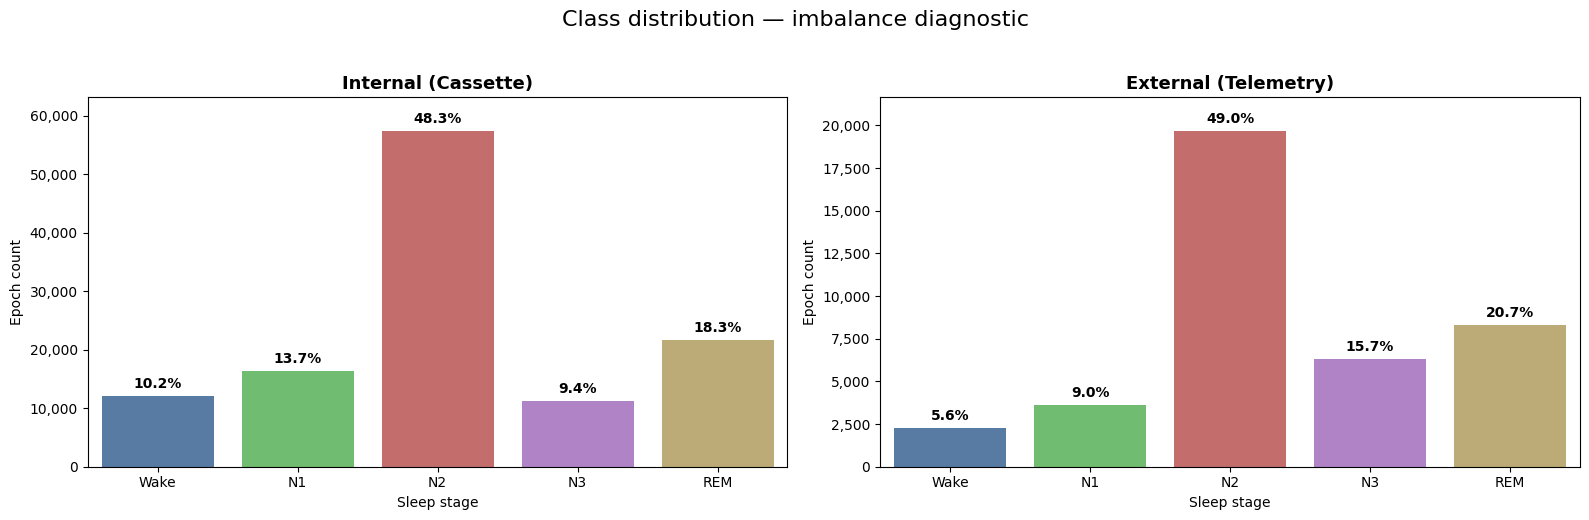

In [29]:
def build_distribution_df(folder_name, class_names):
    file_dfs = glob.glob(os.path.join("processed_data", folder_name, "*.csv"))
    if not file_dfs:
        counts = pd.Series(0, index=range(len(class_names)))
    else:
        combined_labels = pd.concat([pd.read_csv(f)['label'] for f in file_dfs], ignore_index=True)
        counts = combined_labels.dropna().astype(np.int8).value_counts(sort=False)
        counts.index = counts.index.astype(int)

    counts = counts.reindex(range(len(class_names)), fill_value=0).sort_index()
    percentages = counts.div(counts.sum() if counts.sum() > 0 else 1).mul(100)

    return pd.DataFrame({
        "Stage": class_names,
        "Count": counts.to_numpy(),
        "Percentage": percentages.to_numpy()
    })


df_cassette_dist = build_distribution_df("cassette", CLASS_NAMES)
df_telemetry_dist = build_distribution_df("telemetry", CLASS_NAMES)

custom_palette = [
    "#4A7BB0",
    "#63C963",
    "#D15F5F",
    "#B378D1",
    "#C7B16B"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Class distribution — imbalance diagnostic",
    fontsize=16,
    y=1.03
)

plot_configs = [
    (axes[0], df_cassette_dist, "Internal (Cassette)"),
    (axes[1], df_telemetry_dist, "External (Telemetry)")
]


for ax, df_dist, title in plot_configs:

    sns.barplot(
        data=df_dist,
        x="Stage",
        y="Count",
        palette=custom_palette,
        ax=ax,
        hue="Stage",
        legend=False
    )

    # Titles & labels
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Sleep stage")
    ax.set_ylabel("Epoch count")

    # Format y-axis
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    # Dynamic y-limit
    max_count = df_dist["Count"].max()
    offset = max_count * 0.015

    ax.set_ylim(0, max_count * 1.1)

    # Percentage labels
    for i, row in df_dist.iterrows():

        if row["Count"] == 0:
            continue

        ax.text(
            i,
            row["Count"] + offset,
            f"{row['Percentage']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()